In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [5]:
import pandas as pd

df = pd.read_csv(r'..\Datasets\prepared_dataset.csv', index_col=0)

In [6]:
df.head()

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


---
## 🔧 STEP 5 — Preprocessing

Four things to do:
1. **Encode label** → convert `malware/goodware` string to `1/0` number
2. **Remove zero-variance features** → features same for all samples = useless
3. **Train/Test split** → with `stratify` to preserve class ratio
4. **SMOTE** → fix class imbalance by generating synthetic minority samples

> ⚠️ **Important:** Apply SMOTE **only on training data**, never on test data

In [ ]:
# X train data(independent )
X = df.drop(columns=['Label'])

# y test data(dependent)
Y = df['Label']

In [18]:
print(f'Features shape: {X.shape}')
print(f'Label shape: {Y.shape}')

Features shape: (4464, 241)
Label shape: (4464,)


In [11]:
X.head()

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
Y.head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: Label, dtype: float64

In [ ]:

le = LabelEncoder()
y_encoded = le.fit_transform(Y)
print(f'\n Label Encoding:')
for original, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(f'   "{original}" → {encoded}')
y = pd.Series(y_encoded, name='label')


🔤 Label Encoding:
   "0.0" → 0
   "1.0" → 1


In [25]:
y_encoded
y

0       1
1       1
2       1
3       1
4       1
       ..
4459    0
4460    0
4461    0
4462    0
4463    0
Name: label, Length: 4464, dtype: int64

### This block removes features (columns) that have no variation at all — i.e., columns where every value is the same.

In [ ]:
from sklearn.feature_selection import VarianceThreshold
before = X.shape[1]

vt = VarianceThreshold(threshold = 0.0)

X_var = vt.fit_transform(X)
X = pd.DataFrame(X_var, columns = X.columns[vt.get_support()])

after = X.shape[1]

print(f'\n Zero-variance features removed: {before - after}')
print(f'   Remaining features: {after}')


✅ Zero-variance features removed: 42
   Remaining features: 199


#### Train/Test split (80% train, 20% test)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, 
                                    random_state = 42,stratify = y)

print(f'\n Train/Test Split:')
print(f'   Train: {X_train.shape[0]} samples')
print(f'   Test:  {X_test.shape[0]} samples')
print(f'   Test class distribution: {dict(pd.Series(y_test).value_counts())}')


 Train/Test Split:
   Train: 3571 samples
   Test:  893 samples
   Test class distribution: {1: np.int64(713), 0: np.int64(180)}


#### Apply SMOTE on training data only


In [32]:
print(f'\n Applying SMOTE to balance training data...')
print(f'   Before SMOTE: {dict(pd.Series(y_train).value_counts())}')

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'   After SMOTE:  {dict(pd.Series(y_train_bal).value_counts())}')
print(f'\n Preprocessing complete!')
print(f'   Final training shape: {X_train_bal.shape}')


 Applying SMOTE to balance training data...
   Before SMOTE: {1: np.int64(2852), 0: np.int64(719)}
   After SMOTE:  {1: np.int64(2852), 0: np.int64(2852)}

 Preprocessing complete!
   Final training shape: (5704, 199)


---
## Feature Selection

**Why reduce features?**
- TUANDROMD has 241 features — many may be noisy or redundant
- Fewer, better features = faster training + better accuracy
- We use a quick Random Forest to rank all features by importance
- Then keep only the **top 50**

#### Running Feature Selection using Random Forest...
##### (Training a quick RF just to rank feature importance)

In [42]:
from sklearn.ensemble import RandomForestClassifier
import joblib
selector_rf = RandomForestClassifier(
    n_estimators= 100,
    random_state= 42,
    n_jobs = -1
)
selector_rf.fit(X_train_bal, y_train_bal)

# Get feature importances
importances = pd.Series(
    selector_rf.feature_importances_,
    index = X_train_bal.columns
    
).sort_values(ascending = False)

top_features = importances.head(50).index.tolist()


In [56]:
print(f'\n Selected top 50 features out of {X_train_bal.shape[1]} ')

print(f'\n Top 10 most important features:')

for i,(feat, score) in enumerate(importances.head(10).items(),1):
    print(f'   {i}. {feat:<65} {score:.4f}')



 Selected top 50 features out of 199 

 Top 10 most important features:
   1. RECEIVE_BOOT_COMPLETED                                            0.1479
   2. Ljava/net/URL;->openConnection                                    0.0940
   3. GET_TASKS                                                         0.0883
   4. WAKE_LOCK                                                         0.0692
   5. KILL_BACKGROUND_PROCESSES                                         0.0662
   6. Landroid/location/LocationManager;->getLastK0wnLocation           0.0610
   7. READ_PHONE_STATE                                                  0.0324
   8. SYSTEM_ALERT_WINDOW                                               0.0278
   9. Ljava/lang/System;->loadLibrary                                   0.0270
   10. Ljava/lang/System;->load                                          0.0258


In [58]:
# Apply selection

print(f'\n   Train shape before selection: {X_train_bal.shape}')
print(f'   Test shape before selection:  {X_test.shape}')

X_train_sel = X_train_bal[top_features]
X_test_sel  = X_test[top_features]

print(f'\n   Train shape after selection: {X_train_sel.shape}')
print(f'   Test shape after selection:  {X_test_sel.shape}')


   Train shape before selection: (5704, 199)
   Test shape before selection:  (893, 199)

   Train shape after selection: (5704, 50)
   Test shape after selection:  (893, 50)


### Plot top 20 features


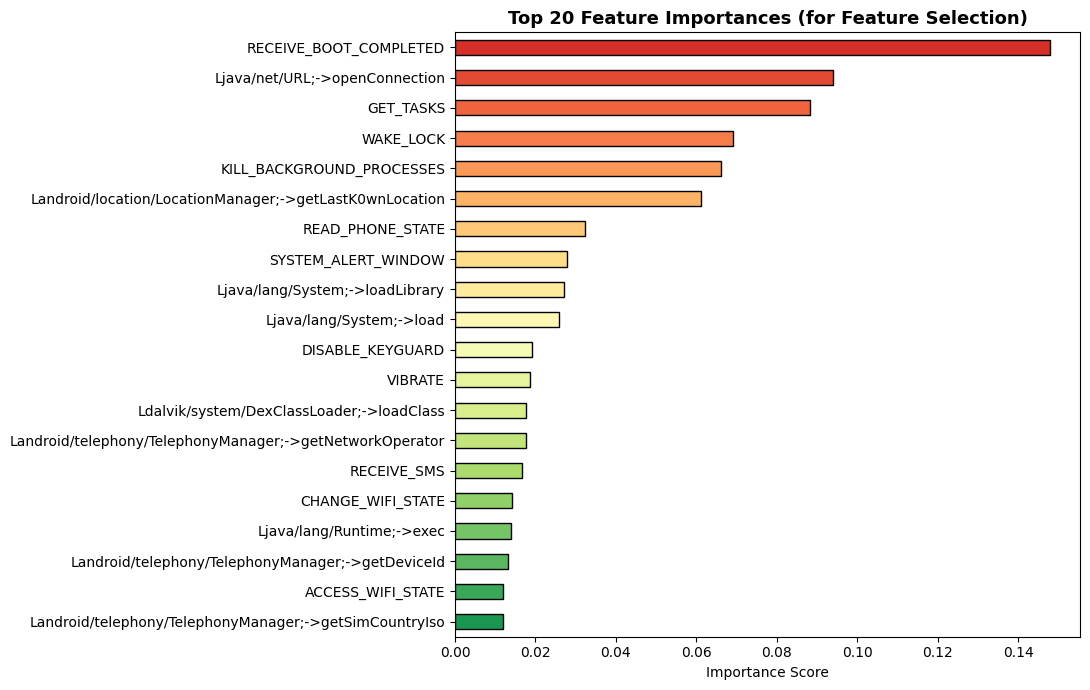

In [62]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(11, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 20))
importances.head(20).sort_values().plot(
    kind='barh',
    color=colors,
    edgecolor='black'
)
plt.title('Top 20 Feature Importances (for Feature Selection)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('03_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

---

##           Train All 4 Models
We train 4 models and compare them:

| Model | Why we train it |
|---|---|
| Logistic Regression | Baseline — simplest model, establishes minimum performance |
| Random Forest | Strong, explainable — handles non-linear feature combinations |
| XGBoost | Best classical ML for tabular data — industry standard |
| Voting Ensemble | Combines all 3 — most stable, used in production |

# ════════════════════════════════════════
# MODEL 1: Logistic Regression (Baseline)

# WHY THIS MODEL:
>  • Simplest model — establishes baseline performance

>  • Every other model MUST beat this score

>  • Linear — cannot capture feature combinations
      e.g., SMS + Overlay together is suspicious,
      but LR treats them independently
      
>  • Uses StandardScaler because LR is scale-sensitive

In [ ]:
# ── Core ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# ── Preprocessing ─────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline

# ── Models ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# ── Evaluation ────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# ── Explainability ────────────────────────────────────
import shap
shap.initjs()  # enables interactive SHAP plots in Jupyter

print('✅ All imports successful!')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
